In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import json
from pathlib import Path

## 1. Configuración de Rutas

In [17]:
# Rutas a los directorios de salida de cada arquitectura
base_path = Path('../outputs/comparison_02')

models = {
    'DenseNet121': base_path / 'densenet121_20260111_090433',
    'EfficientNet-B0': base_path / 'efficientnet-b0_20260111_015704',
    'ResNet50': base_path / 'resnet50_20260111_002544'
}

# Verificar que las rutas existan
for name, path in models.items():
    if not path.exists():
        print(f"⚠️ Advertencia: {name} - Ruta no encontrada: {path}")
    else:
        print(f"✓ {name} - Ruta encontrada")

✓ DenseNet121 - Ruta encontrada
✓ EfficientNet-B0 - Ruta encontrada
✓ ResNet50 - Ruta encontrada


## 2. Cargar Datos de Predicción

In [18]:
def load_predictions(model_path, dataset='test'):
    """
    Carga los datos de predicción de un modelo.
    
    Args:
        model_path: Ruta al directorio del modelo
        dataset: 'test' o 'validation'
    
    Returns:
        DataFrame con true_label y predicted_score
    """
    file_name = f'prediction_scores_{dataset}.csv'
    file_path = model_path / file_name
    
    if not file_path.exists():
        print(f"Archivo no encontrado: {file_path}")
        return None
    
    df = pd.read_csv(file_path)
    return df

# Cargar predicciones de test para cada modelo
predictions = {}
for name, path in models.items():
    pred = load_predictions(path, dataset='test')
    if pred is not None:
        predictions[name] = pred
        print(f"{name}: {len(pred)} muestras cargadas")

DenseNet121: 17125 muestras cargadas
EfficientNet-B0: 17125 muestras cargadas
ResNet50: 17125 muestras cargadas


## 3. Calcular Curvas ROC

In [19]:
# Calcular curvas ROC y AUC para cada modelo
roc_data = {}

for name, pred_df in predictions.items():
    y_true = pred_df['true_label'].values
    y_scores = pred_df['predicted_score'].values
    
    # Calcular FPR, TPR y umbrales
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    roc_data[name] = {
        'fpr': fpr,
        'tpr': tpr,
        'auc': roc_auc,
        'thresholds': thresholds
    }
    
    print(f"{name} - AUC: {roc_auc:.4f}")

DenseNet121 - AUC: 0.7685
EfficientNet-B0 - AUC: 0.8502
ResNet50 - AUC: 0.9228


## 4. Visualización Comparativa de Curvas ROC


✓ Gráfica guardada en: ../outputs/roc_comparison.png


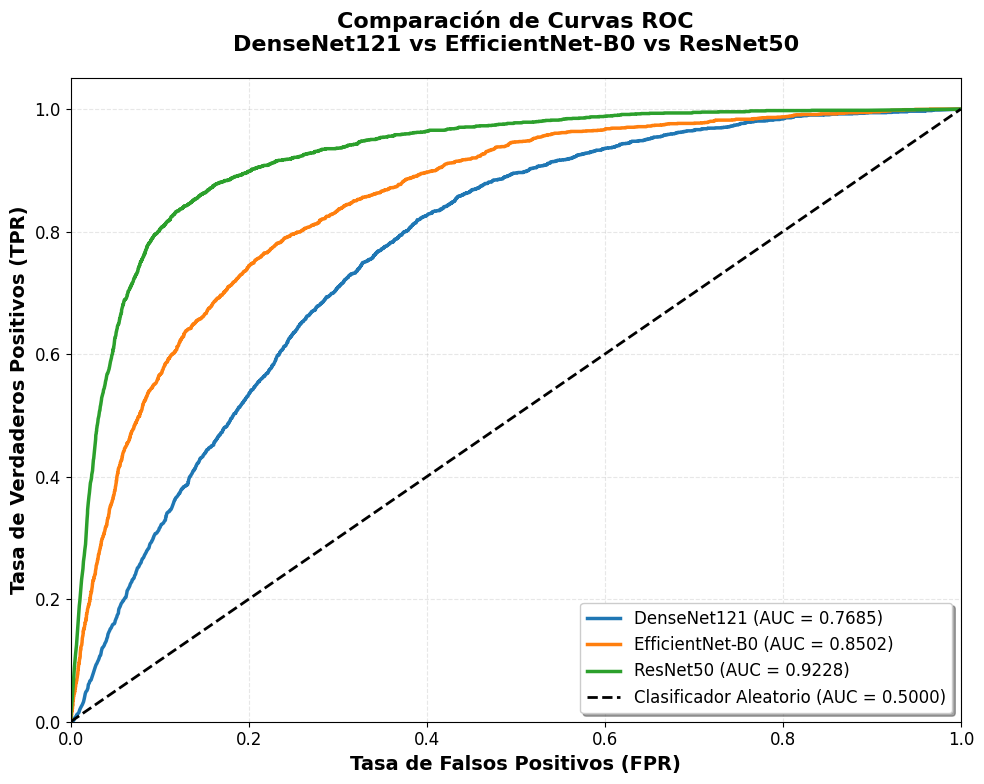

In [20]:
# Configurar el estilo del gráfico
plt.figure(figsize=(10, 8))
plt.rcParams['font.size'] = 12

# Definir colores para cada modelo
colors = {
    'DenseNet121': '#1f77b4',      # Azul
    'EfficientNet-B0': '#ff7f0e',  # Naranja
    'ResNet50': '#2ca02c'          # Verde
}

# Graficar curva ROC para cada modelo
for name, data in roc_data.items():
    plt.plot(
        data['fpr'], 
        data['tpr'], 
        color=colors[name],
        lw=2.5,
        label=f"{name} (AUC = {data['auc']:.4f})"
    )

# Línea diagonal de referencia (clasificador aleatorio)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Clasificador Aleatorio (AUC = 0.5000)')

# Configurar ejes y etiquetas
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=14, fontweight='bold')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=14, fontweight='bold')
plt.title('Comparación de Curvas ROC\nDenseNet121 vs EfficientNet-B0 vs ResNet50', 
          fontsize=16, fontweight='bold', pad=20)

# Leyenda
plt.legend(loc='lower right', fontsize=12, frameon=True, shadow=True)

# Grid
plt.grid(True, alpha=0.3, linestyle='--')

# Ajustar layout
plt.tight_layout()

# Guardar figura
output_path = Path('../outputs/roc_comparison.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Gráfica guardada en: {output_path}")

plt.show()

## 5. Análisis Detallado de Métricas

In [21]:
# Cargar información adicional de cada modelo
print("=" * 80)
print("RESUMEN DE MÉTRICAS POR MODELO")
print("=" * 80)

for name, path in models.items():
    results_path = path / 'results.json'
    if results_path.exists():
        with open(results_path, 'r') as f:
            results = json.load(f)
        
        print(f"\n{name}:")
        print("-" * 80)
        
        # Información del modelo
        if 'model_info' in results:
            print(f"  Timestamp: {results['model_info'].get('timestamp', 'N/A')}")
        
        # Métricas de evaluación
        if 'evaluation_metrics' in results:
            metrics = results['evaluation_metrics']
            print(f"  Test Accuracy: {metrics.get('test_accuracy', 'N/A'):.4f}")
            print(f"  Test AUC: {metrics.get('test_auc', 'N/A'):.4f}")
            print(f"  Test Loss: {metrics.get('test_loss', 'N/A'):.4f}")
            
            if 'test_metrics' in metrics:
                test_metrics = metrics['test_metrics']
                print(f"  Precision: {test_metrics.get('precision', 'N/A'):.4f}")
                print(f"  Recall: {test_metrics.get('recall', 'N/A'):.4f}")
                print(f"  F1-Score: {test_metrics.get('f1_score', 'N/A'):.4f}")
        
        # AUC calculado en este notebook
        if name in roc_data:
            print(f"  AUC (calculado): {roc_data[name]['auc']:.4f}")

print("\n" + "=" * 80)

RESUMEN DE MÉTRICAS POR MODELO



## 6. Tabla Comparativa

In [22]:
# Crear tabla comparativa
comparison_data = []

for name, path in models.items():
    results_path = path / 'results.json'
    if results_path.exists():
        with open(results_path, 'r') as f:
            results = json.load(f)
        
        row = {'Modelo': name}
        
        if 'evaluation_metrics' in results:
            metrics = results['evaluation_metrics']
            row['Accuracy'] = f"{metrics.get('test_accuracy', 0):.4f}"
            row['Loss'] = f"{metrics.get('test_loss', 0):.4f}"
            
            if 'test_metrics' in metrics:
                test_metrics = metrics['test_metrics']
                row['Precision'] = f"{test_metrics.get('precision', 0):.4f}"
                row['Recall'] = f"{test_metrics.get('recall', 0):.4f}"
                row['F1-Score'] = f"{test_metrics.get('f1_score', 0):.4f}"
        
        if name in roc_data:
            row['AUC'] = f"{roc_data[name]['auc']:.4f}"
        
        comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
print("\nTABLA COMPARATIVA DE MÉTRICAS")
print("=" * 100)
print(comparison_df.to_string(index=False))
print("=" * 100)


TABLA COMPARATIVA DE MÉTRICAS
Empty DataFrame
Columns: []
Index: []


## 7. Gráfica de Barras Comparativa de AUC


✓ Gráfica de barras guardada en: ../outputs/auc_comparison_bar.png


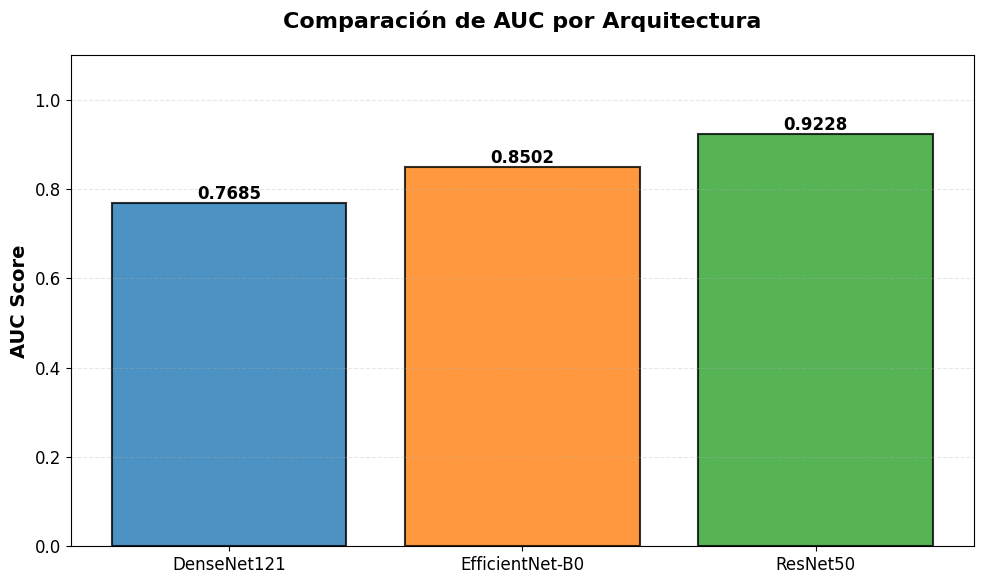

In [23]:
# Gráfica de barras para comparar AUC
fig, ax = plt.subplots(figsize=(10, 6))

model_names = list(roc_data.keys())
auc_values = [roc_data[name]['auc'] for name in model_names]
bar_colors = [colors[name] for name in model_names]

bars = ax.bar(model_names, auc_values, color=bar_colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Añadir valores sobre las barras
for bar, value in zip(bars, auc_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:.4f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('AUC Score', fontsize=14, fontweight='bold')
ax.set_title('Comparación de AUC por Arquitectura', fontsize=16, fontweight='bold', pad=20)
ax.set_ylim([0, 1.1])
ax.grid(True, axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()

# Guardar figura
output_path = Path('../outputs/auc_comparison_bar.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Gráfica de barras guardada en: {output_path}")

plt.show()

## 8. Conclusiones

Este notebook compara las curvas ROC de las tres arquitecturas (DenseNet121, EfficientNet-B0 y ResNet50).

**Interpretación de las curvas ROC:**
- Una curva ROC más cercana a la esquina superior izquierda indica mejor rendimiento
- El AUC (Área Bajo la Curva) cuantifica el rendimiento general del clasificador
- AUC = 1.0: Clasificador perfecto
- AUC = 0.5: Clasificador aleatorio
- Cuanto mayor sea el AUC, mejor es el modelo para discriminar entre clases